In [37]:
import torch 
import matplotlib.pyplot as plt
import numpy as np

from AIce.functions import testloader,redim,Static0Danalysis
from AIce.models import staticNN
from AIce.plotting import RecallPrecisionStatic

In [46]:
# Ensuring the right inputs and target
weight='./weights/staticNN_10inputs_20E_0.001lr_16-19h_21m_00s.pt'
with open(f'{weight[:-3]}.txt', 'r') as f:
    for i in range(2):
        f.readline()
    splits=f.readline().split(':')
    lst=splits[1].strip()
    lst=lst.strip('[]').strip()
    lst=lst.split(',')
    print(lst)
    lst=[x.strip()[1:-1] for x in lst]
    print(lst)


# THERE MUST BE A SMARTER WAY TO KEEP THE VELOCITIES
inputlist=lst
inputlist.append('v_buoy')
inputlist.append('u_buoy')

target='static'

# Load the test_data_following 
datapd,_,_,means,stds,maxes,labels= testloader('../data/DRIFT_DATA_TEST.csv', inputlist=inputlist,target=target,trainingset_loaded=False,training_file='../data/DRIFT_DATA_TRAIN.csv')

print(labels)
# Loading the model
static256=staticNN(len(labels[1])-2)
static256.load_state_dict(torch.load(weight, weights_only=True))# loads the weights onto the model
static256.eval()  # if you're doing inference, not continuing training

inputs=datapd.drop([target,'u_buoy','v_buoy'], axis=1)


out=torch.sigmoid(static256(torch.tensor(inputs.values, dtype = torch.float32))).to('cpu').detach().numpy()

# redim
datapd[inputs.columns]=redim(datapd[inputs.columns],
                    means=means,
                    stds=stds,
                    maxes=maxes)




datapd['output']=out
datapd['buoynorm']= np.sqrt(datapd['u_buoy']**2+datapd['v_buoy']**2)



["'u_ERA5'", " 'v_ERA5'", " 'h_piomas'", " 'sic_CDR'", " 'x_EASE'", " 'y_EASE'", " 'bath'", " 'sin'", " 'cos'", " 'windnorm'"]
['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'x_EASE', 'y_EASE', 'bath', 'sin', 'cos', 'windnorm']
Bath size is the full test set
Target is Staticity with threshold 0.001
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
[Index(['static'], dtype='str'), Index(['x_EASE', 'y_EASE', 'u_buoy', 'v_buoy', 'u_ERA5', 'v_ERA5', 'sic_CDR',
       'h_piomas', 'sin', 'cos', 'bath', 'windnorm'],
      dtype='str')]


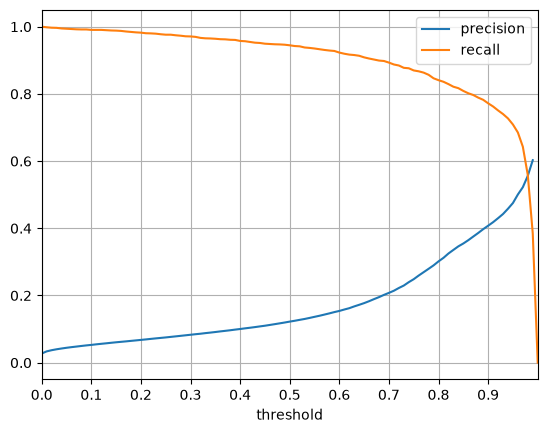

Precision means of the things I called static/moving, how many actually were?
Recall means how many of the real static/moving did I find?
Static Recall % 0.7089100346020761
Moving Recall % 0.9780544879178438
Static Precision % 0.4752102058567701
Moving Precision % 0.9917260880255717
Total Precision % 0.970715540931017


In [47]:
RecallPrecisionStatic(datapd['static'],datapd['output'])

zeroD,true_false_pred=Static0Danalysis(datapd['static'],datapd['output'])


- 20 E no weight; 
Total Accuracy: 87.8958
Moving Recall: 87.9963
Static Recall: 84.2082

- 20 E with weights 36;
Total Accuracy: 89.6638
Moving Recall: 89.8814
Static Recall: 81.6726

- 20 E with weight 64
Total Accuracy: 83.9590
Moving Recall: 83.8953
Static Recall: 86.2989

- 200 E;
Total Accuracy: 92.7514
Moving Recall: 92.8217
Static Recall: 90.1690

- 500 E wiehgt, 64:
Total Accuracy: 93.5227
Moving Recall: 93.6298
Static Recall: 89.5907

- 500 weight 147;
Total Accuracy: 90.8844
Moving Recall: 90.8700
Static Recall: 91.4146

- 874 E;
2248.0 4791.0
Total Accuracy: 96.2483
Moving Recall: 96.5326
Static Recall: 85.8096

- 1000 weight 147
Total Accuracy: 93.9143
Moving Recall: 94.0623
Static Recall: 88.4786

Old label	Old value	=  


Good guess %	X	Total Accuracy = X


Guessed moving wrong %	Y	Moving Recall = 100 − Y


Guess Static Wrong %	Z	Static Recall = 100 − Z


- 20 E no weight; 
Total Precision: 87.8958
Guessed moving wrong: 12.0037
Guess Static Wrong: 15.7918

- 20 E with weights 36;
Total Precision: 89.6638
Falsely Static: 10.1186
Falsely moving: 18.3274

- 20 E with weight 64
Total Precision: 83.9590
Guessed moving wrong: 16.1047
Guess Static Wrong: 13.7011

- 200 E;
Total Precision: 92.7514
Falsely Static: 7.1783
Falsely moving: 9.8310

- 500 E wiehgt, 64:
Total Precision: 93.5227
Guessed moving wrong: 6.3702
Guess Static Wrong: 10.4093

- 500 weight 147;
Total Precision: 90.8844
Guessed moving wrong: 9.1300
Guess Static Wrong: 8.5854

- 874 E;
2248.0 4791.0
Total Precision: 96.2483
Falsely Static: 3.4674
Falsely moving: 14.1904

- 1000 weight 147
Total Precision: 93.9143
Guessed moving wrong: 5.9377
Guess Static Wrong: 11.5214

Precision means of the things I called static/moving, how many actually were?
Recall means how many of the real static/moving did I find?
Static Recall % 0.6453287197231834
Moving Recall % 0.9863840828352146
Static Precision % 0.5705544933078394
Moving Precision % 0.9900211745807677
Total Precision % 0.9770842915944286

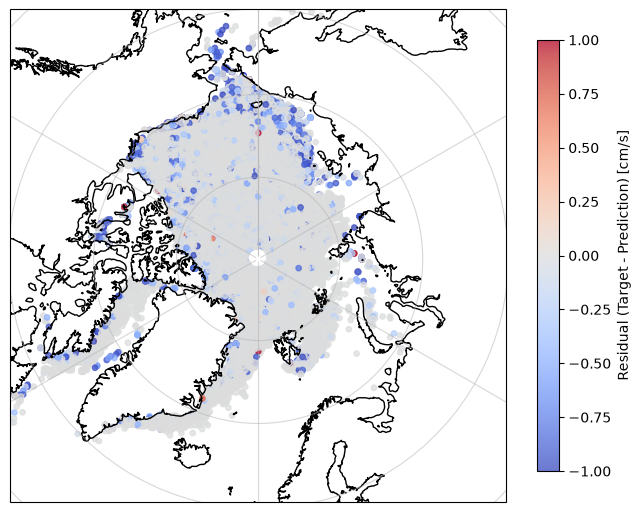

In [43]:
from AIce.plotting import ResidualOnTheMap

ResidualOnTheMap(datapd, pred='output',target='static',vmin=-1,vmax=1)

In [32]:
print(datapd.loc[datapd.index<5])

   static      x_EASE      y_EASE    u_buoy   v_buoy    u_ERA5    v_ERA5  \
0   False  155.338104  135.642914  0.581564  5.08909  2.442403  1.127142   
1   False  137.390686  109.197037 -7.343290  5.48645 -1.543713  7.514323   
2   False  143.100266  135.374527 -9.617448  1.46424  1.953833  2.135191   
3   False  136.624252  124.138580 -3.054050 -4.86851 -4.295371 -1.320883   
4   False  125.033562  139.533203 -5.769730 -7.23450 -2.547196 -2.842972   

    sic_CDR  h_piomas       sin       cos      bath  windnorm    output  \
0  0.996916  2.090739 -0.900969 -0.433884 -3725.000  2.689941  0.053199   
1  1.000000  3.126633 -0.289252  0.957253 -1782.498  7.671252  0.129917   
2  0.995579  1.072999 -0.978624  0.205660 -3669.726  2.894220  0.000298   
3  1.000000  2.497801  0.205660  0.978624 -3571.450  4.493879  0.364750   
4  0.608846  0.995868  0.017261 -0.999851  -404.732  3.817158  0.440687   

   buoynorm  
0  5.122212  
1  9.166517  
2  9.728273  
3  5.747139  
4  9.253528  


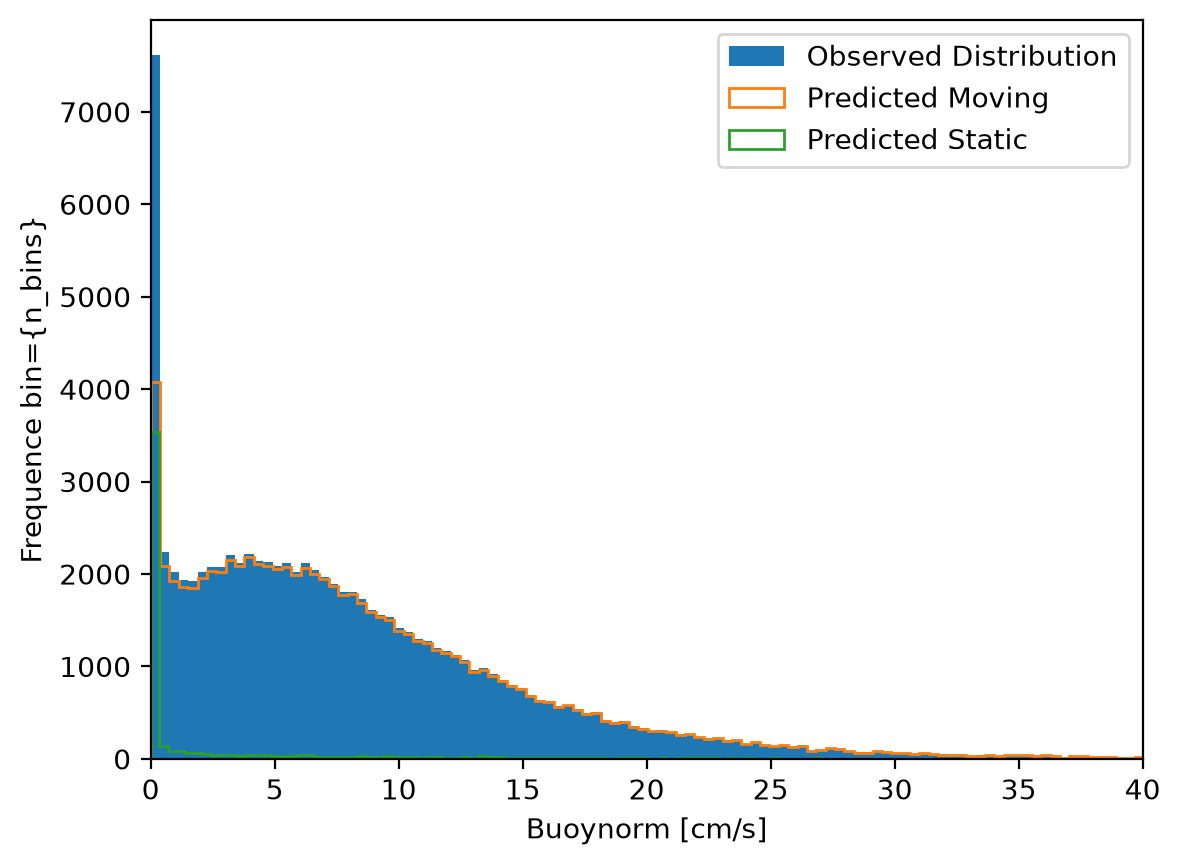

In [44]:
fig, ax =plt.subplots(dpi=200)
n_bins=200
ax.hist(datapd['buoynorm'], n_bins, label='Observed Distribution')
ax.hist(datapd['buoynorm'].loc[datapd['output']<=.8], n_bins, histtype='step', label='Predicted Moving')
ax.hist(datapd['buoynorm'].loc[datapd['output']>=.8], n_bins, histtype='step', label='Predicted Static')


ax.legend()
#plt.xlim([-np.pi,np.pi])
ax.set_xlim([-0,40])
ax.set_ylabel('Frequence bin={n_bins}')
ax.set_xlabel('Buoynorm [cm/s]')
ax.legend()
plt.show()